# 测试集批量预测

同济子豪兄 2023-1-31 6-11

## 进入MMSegmentation主目录

In [36]:
# import os
# os.chdir('mmsegmentation')

import os
# 假设 mmsegmentation 的绝对路径是 /project/mmsegmentation
mmsegmentation_path = "E:/bishe_demo/mmsegmentation-main"
# 切换到 mmsegmentation 文件夹
os.chdir(mmsegmentation_path)
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: /project/mmsegmentation

当前工作目录: E:\bishe_demo\mmsegmentation-main


In [37]:
os.getcwd()

'E:\\bishe_demo\\mmsegmentation-main'

## 导入工具包

In [38]:
import os
import numpy as np
import cv2
from tqdm import tqdm

from mmseg.apis import init_model, inference_model, show_result_pyplot
import mmcv

import matplotlib.pyplot as plt
%matplotlib inline

## 载入模型

In [39]:
# 模型 config 配置文件
config_file = 'Zihao-Configs/ZihaoDataset_PSPNet_20230818.py'

# 模型 checkpoint 权重文件
checkpoint_file = 'work_dirs/ZihaoDataset-PSPNet/best_mIoU_iter_1000.pth'

# device = 'cpu'
device = 'cuda:0'

In [40]:
model = init_model(config_file, checkpoint_file, device=device)

Loads checkpoint by local backend from path: work_dirs/ZihaoDataset-PSPNet/best_mIoU_iter_1000.pth


E:\bishe_demo\mmsegmentation-main\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


## 指定各个类别的配色方案

In [41]:
# # 每个类别的 BGR 配色
# palette = [
#     ['background', [127,127,127]],
#     ['red', [0,0,200]],
#     ['green', [0,200,0]],
#     ['white', [144,238,144]],
#     ['seed-black', [30,30,30]],
#     ['seed-white', [8,189,251]]
# ]

# 自定义 Cityscapes 19 个类别的配色方案（BGR 格式）
palette = [
    ['road', [100, 100, 100]],  # 道路
    ['sidewalk', [200, 50, 200]],  # 人行道
    ['building', [50, 50, 50]],  # 建筑
    ['wall', [150, 150, 200]],  # 墙
    ['fence', [200, 150, 150]],  # 栅栏
    ['pole', [150, 150, 150]],  # 杆子
    ['traffic light', [255, 200, 0]],  # 交通灯
    ['traffic sign', [255, 255, 0]],  # 交通标志
    ['vegetation', [0, 200, 0]],  # 植被
    ['terrain', [200, 255, 200]],  # 地形
    ['sky', [0, 150, 255]],  # 天空
    ['person', [255, 0, 0]],  # 人
    ['rider', [255, 100, 0]],  # 骑行者
    ['car', [0, 0, 255]],  # 汽车
    ['truck', [0, 0, 150]],  # 卡车
    ['bus', [0, 100, 150]],  # 公交车
    ['train', [0, 150, 150]],  # 火车
    ['motorcycle', [0, 0, 200]],  # 摩托车
    ['bicycle', [200, 0, 100]]  # 自行车
]

palette_dict = {}
for idx, each in enumerate(palette):
    palette_dict[idx] = each[1]

In [42]:
palette_dict

{0: [100, 100, 100],
 1: [200, 50, 200],
 2: [50, 50, 50],
 3: [150, 150, 200],
 4: [200, 150, 150],
 5: [150, 150, 150],
 6: [255, 200, 0],
 7: [255, 255, 0],
 8: [0, 200, 0],
 9: [200, 255, 200],
 10: [0, 150, 255],
 11: [255, 0, 0],
 12: [255, 100, 0],
 13: [0, 0, 255],
 14: [0, 0, 150],
 15: [0, 100, 150],
 16: [0, 150, 150],
 17: [0, 0, 200],
 18: [200, 0, 100]}

## 创建空文件夹，存放测试集预测结果

In [43]:
if not os.path.exists('outputs/testset-pred'):
    os.mkdir('outputs/testset-pred')

## 指定测试集路径（也可改成待测图像文件夹路径）

In [44]:
PATH_IMAGE = 'data/cityscapes/leftImg8bit/test/berlin'

In [45]:
os.chdir(PATH_IMAGE)

## 单张图像预测函数

In [46]:
opacity = 0.3 # 透明度，越大越接近原图

In [47]:
def process_single_img(img_path, save=False):

    img_bgr = cv2.imread(img_path)

    # 语义分割预测
    result = inference_model(model, img_bgr)
    pred_mask = result.pred_sem_seg.data[0].cpu().numpy()

    # 将预测的整数ID，映射为对应类别的颜色
    pred_mask_bgr = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3))
    for idx in palette_dict.keys():
        pred_mask_bgr[np.where(pred_mask==idx)] = palette_dict[idx]
    pred_mask_bgr = pred_mask_bgr.astype('uint8')

    # 将语义分割预测图和原图叠加显示
    pred_viz = cv2.addWeighted(img_bgr, opacity, pred_mask_bgr, 1-opacity, 0)

    # 保存图像至 outputs/testset-pred 目录
    if save:
        save_path = os.path.join('../','../','../','../','../','outputs', 'testset-pred', 'pred-'+img_path.split('/')[-1])
        cv2.imwrite(save_path, pred_viz)


## 测试集批量预测

In [48]:
for each in tqdm(os.listdir()):
    process_single_img(each, save=True)

100%|██████████| 544/544 [03:35<00:00,  2.52it/s]


预测结果保存在 `mmsegmentation/outputs/testset-pred` 目录下

In [49]:
# os.chdir(os.path.join('../','../','../'))

import os
# 假设 mmsegmentation 的绝对路径是 /project/mmsegmentation
mmsegmentation_path = "E:/bishe_demo/mmsegmentation-main"
# 切换到 mmsegmentation 文件夹
os.chdir(mmsegmentation_path)
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: /project/mmsegmentation

当前工作目录: E:\bishe_demo\mmsegmentation-main


## 删除系统自动生成的多余文件

### 查看待删除的多余文件

In [15]:
!find . -iname '__MACOSX'

In [16]:
!find . -iname '.DS_Store'

In [17]:
!find . -iname '.ipynb_checkpoints'

./configs/_base_/datasets/.ipynb_checkpoints
./mmseg/datasets/.ipynb_checkpoints
./tools/.ipynb_checkpoints
./checkpoint/.ipynb_checkpoints
./图表/.ipynb_checkpoints
./Zihao-Configs/.ipynb_checkpoints
./work_dirs/ZihaoDataset-PSPNet/20230818_210528/vis_data/.ipynb_checkpoints
./work_dirs/ZihaoDataset-PSPNet/20230818_210528/.ipynb_checkpoints
./work_dirs/ZihaoDataset-PSPNet/.ipynb_checkpoints
./work_dirs/ZihaoDataset-PSPNet/20230819_120941/.ipynb_checkpoints


### 删除多余文件

In [18]:
!for i in `find . -iname '__MACOSX'`; do rm -rf $i;done

In [19]:
!for i in `find . -iname '.DS_Store'`; do rm -rf $i;done

In [20]:
!for i in `find . -iname '.ipynb_checkpoints'`; do rm -rf $i;done

### 验证多余文件已删除

In [21]:
!find . -iname '__MACOSX'

In [22]:
!find . -iname '.DS_Store'

In [23]:
!find . -iname '.ipynb_checkpoints'

## 测试集批量预测结果可视化

In [50]:
os.chdir('outputs/testset-pred')

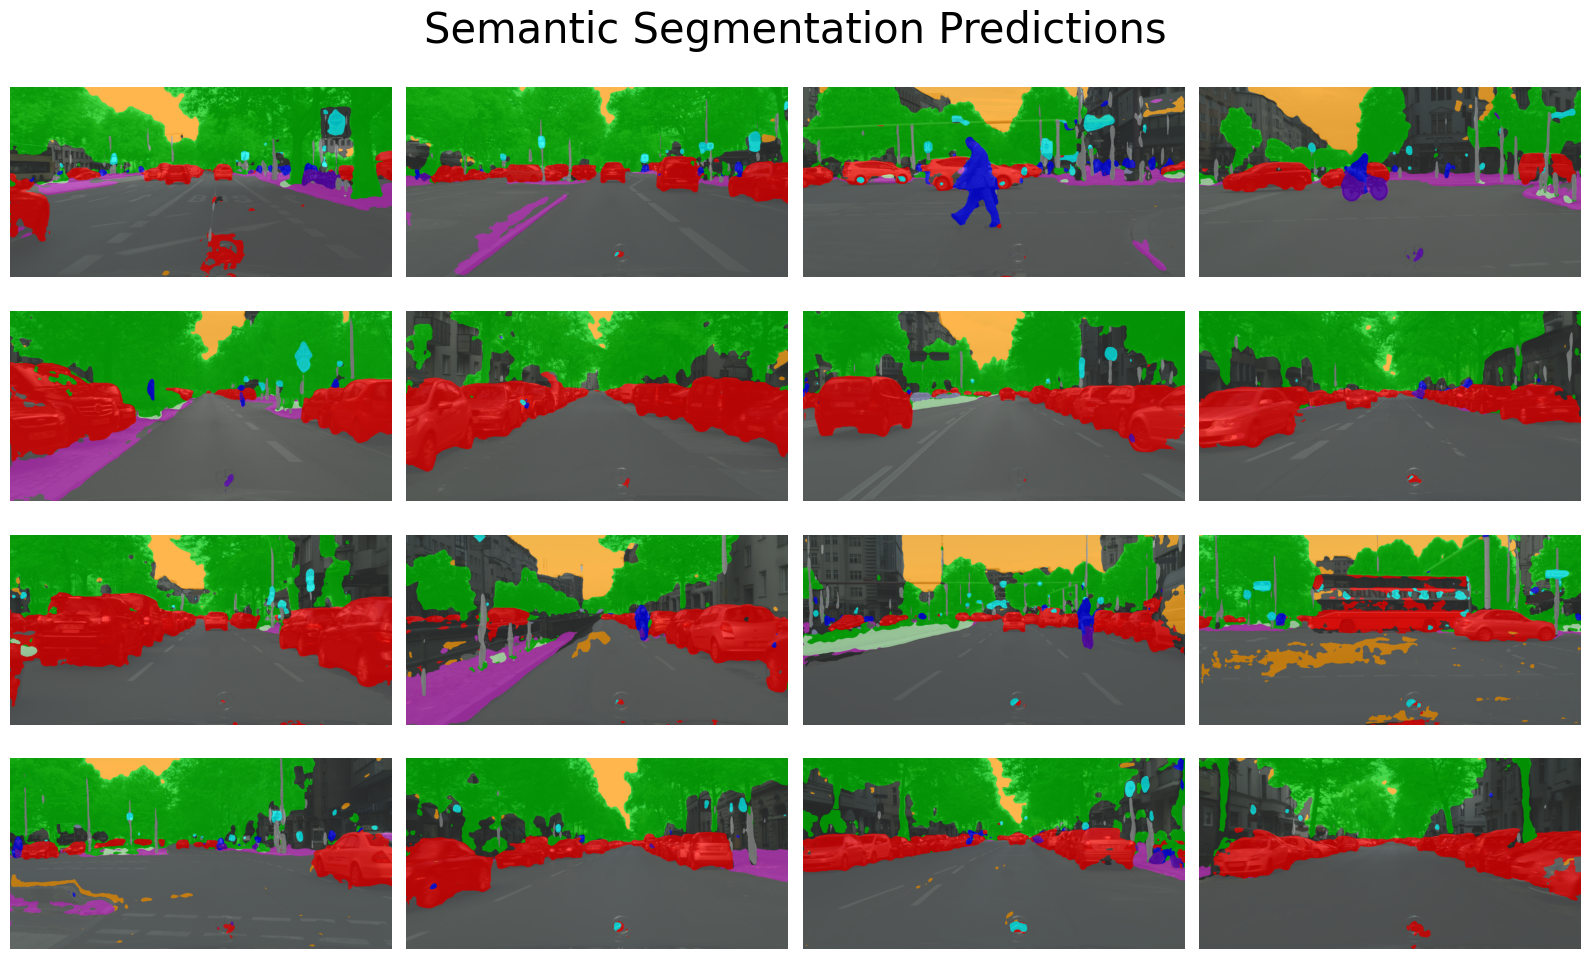

In [51]:
# n 行 n 列可视化
n = 4

fig, axes = plt.subplots(nrows=n, ncols=n, figsize=(16, 10))

for i, file_name in enumerate(os.listdir()[:n**2]):
    
    img_bgr = cv2.imread(file_name)
    
    # 可视化
    axes[i//n, i%n].imshow(img_bgr[:,:,::-1])
    axes[i//n, i%n].axis('off') # 关闭坐标轴显示
fig.suptitle('Semantic Segmentation Predictions', fontsize=30)
plt.tight_layout()
plt.savefig('../K3.jpg')
plt.show()

## 注意：用于预测的图片，不能是训练集中的图片